# Summary: Representation Learning: A Review and New Perspectives (Bengio, Courville, Vincent, 2013)

# https://arxiv.org/pdf/1206.5538

## Abstract
This paper surveys the field of representation learning, arguing that the performance of machine learning algorithms is fundamentally shaped by the choice of data representation, and that learning representations directly from data—rather than relying on hand-engineered features—is key to progress toward AI. The authors review advances in probabilistic graphical models, autoencoders, manifold learning, and deep networks, unifying them under common generic priors, and identify open questions concerning learning objectives, inference, and the geometric relationships between representation learning, density estimation, and manifold learning.

## Problems
- **Dependence on feature engineering**: Machine learning performance is heavily tied to hand-designed features, which is labor-intensive, domain-specific, and limits scalability and generality of learning systems.
- **Curse of dimensionality and local generalization**: Classical non-parametric methods (e.g., kernel machines with local kernels) rely on smoothness priors and local interpolation, which fail to scale to AI-level tasks where the number of relevant variations grows exponentially with input dimensionality.
- **Ill-defined training objectives for representation learning**: Unlike supervised classification, there is no obvious target objective for learning "good" representations, since the ultimate goal (e.g., downstream classification) is far removed from the unsupervised training criterion.
- **Intractable inference and training in deep probabilistic models**: Directed models suffer from "explaining away," making posterior inference intractable; undirected models (Boltzmann machines) have intractable partition functions; both complicate learning as depth increases.
- **Sampling and mixing difficulties**: MCMC-based training of deep undirected models (e.g., RBMs, DBMs) suffers from poor chain mixing as models sharpen during training, making negative-phase gradient estimation unreliable.
- **Difficulty of jointly training deep architectures**: Gradient-based training of deep networks is prone to vanishing gradients, ill-conditioning, and poor local minima, historically necessitating greedy layer-wise pre-training.

## Proposed Solutions
- **Generic priors for representation learning**: The paper enumerates priors believed to help disentangle underlying explanatory factors of data, including smoothness, multiple explanatory factors, hierarchical organization of factors, semi-supervised sharing, shared factors across tasks, manifold structure, natural clustering, temporal/spatial coherence, sparsity, and simplicity of factor dependencies.
- **Distributed and sparse representations**: Advocates representations where many non-mutually-exclusive features can be active simultaneously (as in RBMs, sparse coding, autoencoders), enabling $$O(2^k)$$ distinguishable configurations with only $$O(N)$$ parameters, versus $$O(N)$$ regions for local/one-hot methods.
- **Deep architectures for abstraction**: Promotes stacking multiple layers of representation to enable feature re-use and increasingly abstract, invariant representations, motivated by circuit-complexity results showing exponential efficiency gains from depth.
- **Single-layer building blocks reviewed and unified**: Surveys RBMs and their real-valued generalizations (GRBM, mcRBM, mPoT, ssRBM), sparse coding and its spike-and-slab variant, and regularized autoencoders (sparse, denoising, contractive, PSD) as complementary approaches to single-layer feature learning.
- **Improved training algorithms**: Reviews Contrastive Divergence, Stochastic Maximum Likelihood (persistent CD), fast-weights PCD, pseudolikelihood, ratio-matching, score matching, and denoising score matching as approximate methods for training undirected energy-based models without requiring full MCMC convergence.
- **Manifold learning perspective**: Frames representation learning geometrically, where regularized autoencoders (denoising, contractive) implicitly estimate the tangent space of a data manifold, connecting representation learning to local density/score estimation.
- **Global/joint training strategies**: Discusses joint training of Deep Boltzmann Machines via mean-field variational inference plus SML, and highlights empirical advances (careful initialization, rectifying non-linearities, dropout, convolutional/pooling architectures) enabling successful training of very deep supervised networks without pre-training.
- **Invariance-building mechanisms**: Reviews convolution and pooling, transformation-invariant training via synthetic data augmentation, temporal/slow-feature coherence, and disentangling-oriented approaches (e.g., Manifold Tangent Classifier, transforming autoencoders) as means to build invariant yet informative features.

## Purpose
To provide a unifying, critical review of representation learning research (probabilistic models, autoencoders, and manifold learning) as of 2013, to articulate the theoretical priors that motivate deep and distributed representations, to catalog empirical successes across speech, vision, and NLP domains, and to identify open research questions on appropriate training objectives, tractable inference, and the connections between generative modeling and feature learning.

## Methodology
- **Literature synthesis and taxonomy**: The paper organizes representation learning into three paradigms—directed probabilistic models, undirected probabilistic models (Boltzmann machines), and direct parametric encoding (autoencoders)—and systematically compares their formulations, tractability, and training algorithms.
- **Mathematical formalization of models**:
  - Sparse coding inference and dictionary learning:
$$h^* = \arg\min_h \|x - Wh\|_2^2 + \lambda\|h\|_1 \qquad J_{SC} = \sum_t \|x^{(t)} - Wh^{*(t)}\|_2^2$$
  - Boltzmann machine energy function:
$$E^{BM}_\theta(x,h) = -\tfrac{1}{2}x^TUx - \tfrac{1}{2}h^TVh - x^TWh - b^Tx - d^Th$$
  - RBM factorized conditionals (obtained by setting $$U=0, V=0$$):
$$P(h|x)=\prod_i P(h_i|x), \quad P(h_i=1|x)=\text{sigmoid}\Big(\sum_j W_{ji}x_j + d_i\Big)$$
  - Boltzmann machine log-likelihood gradient (positive/negative phase):
$$\frac{\partial}{\partial\theta_i}\sum_t \log p(x^{(t)}) = -\sum_t \mathbb{E}_{p(h|x^{(t)})}\Big[\frac{\partial}{\partial\theta_i}E^{BM}_\theta(x^{(t)},h)\Big] + \sum_t \mathbb{E}_{p(x,h)}\Big[\frac{\partial}{\partial\theta_i}E^{BM}_\theta(x,h)\Big]$$
  - Autoencoder reconstruction objective:
$$J_{AE}(\theta) = \sum_t L(x^{(t)}, g_\theta(f_\theta(x^{(t)})))$$
  - Denoising autoencoder objective:
$$J_{DAE} = \sum_t \mathbb{E}_{q(\tilde{x}|x^{(t)})}\big[L(x^{(t)}, g_\theta(f_\theta(\tilde{x})))\big]$$
  - Contractive autoencoder penalty (Frobenius norm of encoder Jacobian):
$$J_{CAE} = \sum_t L(x^{(t)}, g_\theta(f_\theta(x^{(t)}))) + \lambda\|J(x^{(t)})\|_F^2$$
  - Deep Boltzmann Machine energy and variational mean-field lower bound:
$$E^{DBM}_\theta(v,h^{(1)},h^{(2)}) = -v^TWh^{(1)} - h^{(1)T}Vh^{(2)} - d^{(1)T}h^{(1)} - d^{(2)T}h^{(2)} - b^Tv$$
$$\log P(v) \geq \mathcal{L}(Q_v) = \sum_{h^{(1)},h^{(2)}} Q_v(h^{(1)},h^{(2)})\log\frac{P(v,h^{(1)},h^{(2)})}{Q_v(h^{(1)},h^{(2)})}$$
- **Comparative review of training algorithms**: Analyzes Contrastive Divergence, SML/PCD, FPCD, pseudolikelihood, and score matching along dimensions of bias, variance, and computational cost, drawing on empirical comparisons from cited literature (e.g., Marlin et al., 2010).
- **Geometric analysis**: Uses Jacobian singular-value spectra of trained encoders (e.g., Contractive Autoencoders) to empirically demonstrate that learned representations capture low-dimensional tangent spaces of data manifolds.
- **Survey of empirical benchmarks**: Reports outcomes across domains (speech recognition word error rates, MNIST/CIFAR-10/ImageNet classification error, language modeling perplexity, transfer learning challenges) drawn from the broader literature rather than original experiments.

## Results
- Deep learning models reduced word error rates by approximately 30% relative to Gaussian-mixture acoustic models on major speech benchmarks (e.g., 27.4% to 18.5% on RT03S).
- Deep convolutional networks achieved state-of-the-art MNIST error rates as low as 0.27% (Ciresan et al., 2012) and knowledge-free MNIST error of 0.81% (Rifai et al., 2011c).
- On ImageNet (1000-class), deep convolutional networks (Krizhevsky et al., 2012) reduced classification error from 26.1% to 15.3%, a benchmark result attributed to GPU training, large labeled datasets, data augmentation, convolution/pooling, rectifying non-linearities, and dropout.
- Recurrent neural network language models reduced perplexity from 140 to 102 and word error rate from 17.2% to 14.4% on the Wall Street Journal benchmark.
- Sparse coding and spike-and-slab sparse coding (S3C) representations outperformed competing encodings in low-labeled-data regimes (<1000 examples/class) on CIFAR-10/CIFAR-100, with S3C winning the NIPS 2011 Transfer Learning Challenge.
- Denoising and Contractive Autoencoders won the final phase of the Unsupervised and Transfer Learning Challenge (2011); CAE representations were shown (via Jacobian SVD analysis) to exhibit a sharply decreasing singular value spectrum, supporting the hypothesis that they model low-dimensional manifold tangent spaces.
- Naive joint SML-based training of Deep Boltzmann Machines was found vulnerable to poor local minima with "dead" hidden units, motivating continued reliance on greedy layer-wise pre-training followed by joint fine-tuning.
- Studies (Erhan et al., 2010b) attributed the benefit of unsupervised pre-training to both a regularization effect (biasing optimization toward generalizable minima) and an optimization effect, though the latter remains only partially understood.
- Recent large-labeled-data results indicate that with proper initialization and non-linearities, very deep purely supervised networks can be trained successfully without layer-wise pre-training, suggesting pre-training acts primarily as a prior that becomes less critical at large data scale.

## Conclusions
The paper concludes that representation learning has matured into three interconnected paradigms—probabilistic (directed and undirected) models, reconstruction-based autoencoders, and manifold learning—whose theoretical and empirical connections are an active and productive research area. The authors emphasize that incorporating generic AI-level priors (multiple disentangled factors, hierarchical/deep organization, sparsity, temporal coherence) into representation learning algorithms is central to progress toward AI, and that future work must address three long-term open questions: (1) what constitutes an appropriate training objective for representation learning in the absence of a clear downstream target; (2) how to perform tractable, possibly learned, approximate inference in the presence of highly multimodal posteriors; and (3) how to better understand and resolve the optimization difficulties (local minima, ill-conditioning, sampling/mixing challenges) that arise when jointly training deep architectures.

# Mathematical and Statistical Content: Representation Learning: A Review and New Perspectives

## 1. Probabilistic PCA (Factor Analysis View)

$$p(h) = \mathcal{N}(h; 0, \sigma_h^2 I)$$
$$p(x \mid h) = \mathcal{N}(x; Wh + \mu_x, \sigma_x^2 I) \tag{1}$$

**Meaning:** PCA is reinterpreted probabilistically: a latent Gaussian factor $$h$$ is linearly mapped to the data $$x$$ plus Gaussian noise. This connects the classic dimensionality-reduction algorithm to the paper's broader framework of directed latent-variable models, and shows PCA is a special (linear, Gaussian) case of representation learning.

## 2. Sparse Coding

**Inference (finding the code for a given input):**
$$h^* = f(x) = \arg\min_h \|x - Wh\|_2^2 + \lambda\|h\|_1 \tag{2}$$
Finds a sparse vector $$h$$ (mostly zeros) that reconstructs $$x$$ well using a dictionary $$W$$. The $$L_1$$ penalty encourages sparsity — only a few "basis" directions are used to explain any given input.

**Dictionary learning objective:**
$$J_{SC} = \sum_t \|x^{(t)} - Wh^{*(t)}\|_2^2 \tag{3}$$
Learns the dictionary $$W$$ by minimizing reconstruction error over all training examples, using the sparse codes found via Eq. (2).

**Probabilistic (Laplace prior) version:**
$$p(h) = \prod_i \frac{\lambda}{2}\exp(-\lambda|h_i|), \qquad p(x\mid h) = \mathcal{N}(x; Wh+\mu_x, \sigma_x^2 I) \tag{4}$$
Replaces the Gaussian prior of PCA with a Laplace (sharply peaked at zero) prior on $$h$$, which is the probabilistic justification for the $$L_1$$ sparsity penalty. The paper uses this to explain sparse coding's "explaining away" property: only a few dictionary elements are used to explain each input, and these compete/collaborate to do so.

## 3. Undirected Graphical Models (Markov Random Fields)

**General clique-potential factorization:**
$$p(x,h) = \frac{1}{Z_\theta}\prod_i \psi_i(x)\prod_j \eta_j(h)\prod_k \nu_k(x,h) \tag{5}$$
Defines probability as a product of non-negative compatibility functions (potentials) between variables, normalized by the partition function $$Z_\theta$$ (a sum over all configurations, generally intractable).

**Boltzmann distribution (energy-based form):**
$$p(x,h) = \frac{1}{Z_\theta}\exp(-E_\theta(x,h)) \tag{6}$$
Converts an energy function into a probability: low-energy configurations are more probable. This is the general form underlying RBMs and Boltzmann Machines.

## 4. Boltzmann Machine

**Energy function:**
$$E^{BM}_\theta(x,h) = -\tfrac{1}{2}x^TUx - \tfrac{1}{2}h^TVh - x^TWh - b^Tx - d^Th \tag{7}$$
Captures visible-visible ($$U$$), hidden-hidden ($$V$$), and visible-hidden ($$W$$) interactions, plus bias terms. This is the most general (fully-connected) undirected model discussed.

**Partition function:**
$$Z_\theta = \sum_{x}\sum_{h}\exp(-E^{BM}_\theta(x,h;\theta)) \tag{8}$$
The normalizing constant, summing over all possible visible and hidden configurations — computationally intractable for large models, which is the central obstacle to training Boltzmann Machines.

**Conditional distributions:**
$$P(h_i\mid x,h_{\backslash i}) = \text{sigmoid}\Big(\sum_j W_{ji}x_j + \sum_{i'\neq i}V_{ii'}h_{i'} + d_i\Big) \tag{9}$$
$$P(x_j\mid h,x_{\backslash j}) = \text{sigmoid}\Big(\sum_i W_{ji}x_j + \sum_{j'\neq j}U_{jj'}x_{j'} + b_j\Big) \tag{10}$$
Each unit's activation probability is a sigmoid of a weighted sum of its neighbors — the standard "neuron" equation, but here neighbors include same-layer units too, making exact inference intractable (requires summing over $$2^{d_h-1}$$ hidden configurations, Eq. 11).

## 5. Restricted Boltzmann Machine (RBM)

By setting $$U=0, V=0$$ (no within-layer connections), the conditionals **factorize**:
$$P(h\mid x) = \prod_i P(h_i\mid x), \qquad P(h_i=1\mid x) = \text{sigmoid}\Big(\sum_j W_{ji}x_j + d_i\Big) \tag{12}$$
$$P(x\mid h) = \prod_j P(x_j\mid h), \qquad P(x_j=1\mid h) = \text{sigmoid}\Big(\sum_i W_{ji}h_i + b_j\Big) \tag{13}$$

**Meaning:** Removing intra-layer connections makes both conditionals independent products of sigmoids — this is what makes RBMs tractable for inference (feature extraction), even though the partition function $$Z_\theta$$ (needed for exact likelihood) is still intractable, only bounded by $$\min\{2^{d_x}, 2^{d_h}\}$$ terms.

## 6. RBM Training: Log-Likelihood and Its Gradient

**Training log-likelihood:**
$$\sum_{t=1}^T \log P(x^{(t)};\theta) = \sum_{t=1}^T \log\sum_{h\in\{0,1\}^{d_h}} P(x^{(t)},h;\theta) \tag{14}$$

**Gradient (general Boltzmann machine form):**
$$\frac{\partial}{\partial\theta_i}\sum_t \log p(x^{(t)}) = -\sum_t \mathbb{E}_{p(h\mid x^{(t)})}\Big[\frac{\partial}{\partial\theta_i}E^{BM}_\theta(x^{(t)},h)\Big] + \sum_t \mathbb{E}_{p(x,h)}\Big[\frac{\partial}{\partial\theta_i}E^{BM}_\theta(x,h)\Big] \tag{15}$$

**Meaning:** This is the "positive phase minus negative phase" gradient central to all Boltzmann-machine training. The first term (clamped/positive phase, tractable for RBMs) pushes down the energy of real data. The second term (unclamped/negative phase, generally intractable) pushes up the energy of model samples. Training converges when these two forces balance.

**Monte Carlo approximation of the negative phase (via Gibbs sampling):**
$$\mathbb{E}_{p(x,h)}\Big[\frac{\partial}{\partial\theta_i}E^{RBM}_\theta(x,h)\Big] \approx \frac{1}{L}\sum_{l=1}^L \frac{\partial}{\partial\theta_i}E^{RBM}_\theta(\tilde{x}^{(l)},\tilde{h}^{(l)}) \tag{16}$$
with samples drawn via alternating (block) Gibbs sampling:
$$\tilde{x}^{(l)} \sim P(x\mid \tilde{h}^{(l-1)}), \qquad \tilde{h}^{(l)} \sim P(h\mid \tilde{x}^{(l)})$$

**Meaning:** Because exact expectation over the joint distribution is intractable, it is approximated by averaging over samples drawn from a Gibbs chain. The challenge is that a full Gibbs chain needs to "burn in" to converge — which is too slow for practical training, motivating the approximations below.

## 7. Contrastive Divergence (CD)

Estimates the negative-phase expectation using a very short Gibbs chain (often just 1 step) initialized at the training data, instead of waiting for full convergence.

**Meaning:** Trades some bias (the short chain doesn't reach the true model distribution) for a massive reduction in computational cost, making RBM training practical. This is the most widely used RBM training method discussed.

## 8. Stochastic Maximum Likelihood (SML) / Persistent Contrastive Divergence (PCD)

Instead of restarting the Gibbs chain at the data each update (as in CD), SML keeps a **persistent** Markov chain running across updates, using its last state as the starting point for the next.

**Meaning:** Since model parameters change slowly, the chain stays close to the model's equilibrium distribution without needing to re-converge each step — but this requires good "mixing" (the chain must be able to move between different modes/regions of high probability), which becomes harder as training progresses and the learned distribution becomes sharper/more peaked.

## 9. Fast-Weights Persistent Contrastive Divergence (FPCD)

**Fast-weight update rule:**
$$\theta^*_{t+1} = (1-\eta)\theta_{t+1} + \eta\theta^*_t + \epsilon^*\frac{\partial}{\partial\theta_i}\Big(\sum_{t=1}^T \log p(x^{(t)})\Big) \tag{17}$$

**Meaning:** Introduces a second, faster-moving copy of the parameters (with a larger learning rate $$\epsilon^* > \epsilon$$ and a forgetting factor $$\eta$$) used only for generating negative-phase samples. This "perturbed" model helps the Gibbs chain mix faster between modes, addressing the sampling stagnation problem of SML, at the cost of occasionally generating less faithful (spurious) samples.

## 10. Free Energy

$$F(x;\theta) = -\log P(x) - \log Z_\theta$$

**Meaning:** A tractable quantity for RBMs (unlike the full joint), representing an unnormalized log-probability of the visible units alone (after marginalizing out hidden units). Used as the basis for pseudolikelihood, ratio-matching, and score-matching training criteria that avoid explicitly computing $$Z_\theta$$.

## 11. Autoencoders

**Encoding/decoding and reconstruction objective:**
$$h^{(t)} = f_\theta(x^{(t)}) \tag{18}$$
$$J_{AE}(\theta) = \sum_t L(x^{(t)}, g_\theta(f_\theta(x^{(t)}))) \tag{19}$$
An encoder $$f_\theta$$ maps input to a code $$h$$; a decoder $$g_\theta$$ maps the code back to a reconstruction; parameters are trained to minimize reconstruction error $$L$$ (e.g., squared error or cross-entropy) directly, without any explicit probability model.

**Standard affine + non-linearity parametrization:**
$$f_\theta(x) = s_f(b+Wx), \qquad g_\theta(h) = s_g(d+W'h) \tag{20,21}$$
The simplest, most common autoencoder architecture — linear transformation followed by an optional non-linearity (sigmoid/tanh) — mirroring the form of RBM conditionals when both use sigmoid activations.

**Meaning:** Unlike probabilistic models, autoencoders don't require computing an intractable partition function; they optimize a simple, tractable reconstruction loss, making them a practically appealing alternative to RBMs for learning single-layer features. A key design challenge is preventing the model from just learning the identity function (perfect but useless reconstruction) — this motivates the regularized variants below.

## 12. Denoising Autoencoder (DAE)

$$J_{DAE} = \sum_t \mathbb{E}_{q(\tilde{x}\mid x^{(t)})}\big[L(x^{(t)}, g_\theta(f_\theta(\tilde{x})))\big] \tag{22}$$

**Meaning:** The model is trained to reconstruct the *clean* input from a *corrupted* (noisy) version $$\tilde{x}$$. This forces the network to learn the actual structure of the data distribution (rather than the identity function), since it must "undo" the corruption using learned statistical regularities. Theoretically, the reconstruction function $$r(\tilde{x}) - \tilde{x}$$ approximates the score (gradient of the log-density), i.e., a vector field pointing toward high-density regions (the data manifold).

## 13. Contractive Autoencoder (CAE)

**Jacobian-penalized objective:**
$$J_{CAE} = \sum_t L(x^{(t)}, g_\theta(f_\theta(x^{(t)}))) + \lambda\|J(x^{(t)})\|_F^2 \tag{23}$$
where $$J(x) = \frac{\partial f_\theta}{\partial x}(x)$$ is the encoder's Jacobian matrix.

**Explicit form for a sigmoid encoder:**
$$J_j(x) = f_\theta(x)_j(1-f_\theta(x)_j)W_j$$
$$\|J(x)\|_F^2 = \sum_j (f_\theta(x)_j(1-f_\theta(x)_j))^2\|W_j\|^2 \tag{24}$$

**Meaning:** Adds an analytic penalty (Frobenius norm of the Jacobian) that discourages the encoder from being overly sensitive to small input changes, i.e., it makes the representation locally "flat" (contractive) except in directions where reconstruction actually needs sensitivity. This is a deterministic, differentiable alternative to the stochastic corruption used in DAEs, and gives interpretable "tangent directions" of the learned data manifold.

**Higher-order extension (CAE+H):**
$$J_{CAE+H} = \sum_t L(x^{(t)}, g_\theta(x^{(t)})) + \lambda\|J(x^{(t)})\|_F^2 + \gamma\,\mathbb{E}_\epsilon\big[\|J(x)-J(x+\epsilon)\|_F^2\big] \tag{25}$$
Extends the penalty to also stabilize higher-order derivatives (not just infinitesimal sensitivity), by requiring the Jacobian itself to change smoothly under small perturbations $$\epsilon \sim \mathcal{N}(0,\sigma^2 I)$$.

## 14. Predictive Sparse Decomposition (PSD)

$$J_{PSD} = \sum_t \lambda\|h^{(t)}\|_1 + \|x^{(t)}-Wh^{(t)}\|_2^2 + \|h^{(t)}-f_\alpha(x^{(t)})\|_2^2 \tag{26}$$
$$f_\alpha(x^{(t)}) = \tanh(b+W^Tx^{(t)}) \tag{27}$$

**Meaning:** Combines sparse coding (first two terms) with a fast, parametric encoder $$f_\alpha$$ trained to approximate the (slow, iterative) sparse code $$h^{(t)}$$. This provides the "explaining away" benefits of sparse coding while allowing quick, non-iterative feature extraction at test time — bridging probabilistic sparse coding and direct-encoding autoencoders.

## 15. Local Coordinate Coding (LCC)

$$J_{LCC} = \sum_t \Big(\|x^{(t)}-Wh^{(t)}\|_2^2 + \lambda\sum_j |h_j^{(t)}|\,\|W_{:,j}-x^{(t)}\|^{1+p}\Big) \tag{28}$$

**Meaning:** A manifold-motivated variant of sparse coding: instead of just penalizing code magnitude, it penalizes using dictionary "anchor points" ($$W_{:,j}$$) that are far from the input $$x^{(t)}$$, encouraging locally relevant codes. Theoretically justified by showing that any smooth function on a low-dimensional manifold can be well approximated as a linear function of such codes, with accuracy depending on the manifold's intrinsic dimension rather than the raw input dimension.

## 16. Deep Boltzmann Machine (DBM)

**Two-hidden-layer energy function:**
$$E^{DBM}_\theta(v,h^{(1)},h^{(2)}) = -v^TWh^{(1)} - h^{(1)T}Vh^{(2)} - d^{(1)T}h^{(1)} - d^{(2)T}h^{(2)} - b^Tv \tag{29}$$
A structured Boltzmann machine with layered (bipartite-per-layer-pair) connectivity, generalizing the RBM to multiple hidden layers.

**Mean-field variational lower bound:**
$$\log P(v) \geq \mathcal{L}(Q_v) \equiv \sum_{h^{(1)}}\sum_{h^{(2)}} Q_v(h^{(1)},h^{(2)})\log\frac{P(v,h^{(1)},h^{(2)})}{Q_v(h^{(1)},h^{(2)})} \tag{30}$$
Since the true posterior over hidden units is intractable (unlike the RBM), it is approximated by a factorized distribution $$Q_v$$, and training maximizes a lower bound on the true log-likelihood instead of the likelihood itself.

**Mean-field fixed-point update equations:**
$$\hat{h}^{(1)}_i \leftarrow \text{sigmoid}\Big(\sum_j W_{ji}v_j + \sum_k V_{ik}\hat{h}^{(2)}_k + d^{(1)}_i\Big) \tag{31}$$
$$\hat{h}^{(2)}_k \leftarrow \text{sigmoid}\Big(\sum_i V_{ik}\hat{h}^{(1)}_i + d^{(2)}_k\Big) \tag{32}$$
Iteratively updating each layer's expected activation given the others — analogous to a recurrent neural network computation — until convergence, at which point these values approximate the (intractable) true posterior.

**Gradient of the variational bound:**
$$\frac{\partial\mathcal{L}(Q_v)}{\partial\theta} = -\mathbb{E}_{Q_v}\Big[\frac{\partial E^{DBM}_\theta(v,h^{(1)},h^{(2)})}{\partial\theta}\Big] + \mathbb{E}_P\Big[\frac{\partial E^{DBM}_\theta(v,h^{(1)},h^{(2)})}{\partial\theta}\Big] \tag{33}$$

**Meaning:** Same positive-phase/negative-phase structure as the RBM gradient (Eq. 15), but the positive phase now uses the mean-field approximate posterior $$Q_v$$ (since the true one is intractable), while the negative phase is still estimated via SML/Contrastive Divergence-style sampling.

## Summary Table: Statistical/Mathematical Themes

| Concept | Role in the Paper |
|---|---|
| Probabilistic PCA / factor analysis | Establishes a common probabilistic baseline connecting linear representation learning to later non-linear models |
| Sparse coding (Eqs. 2–4) | Illustrates explaining-away and the MAP-inference approach to directed latent-variable models |
| Boltzmann distribution / energy functions (Eqs. 6–8) | General framework unifying RBMs, DBMs, and other undirected models |
| RBM factorized conditionals (Eqs. 9, 12–13) | Explains why RBMs allow tractable feature inference despite an intractable partition function |
| Log-likelihood gradient / positive-negative phase (Eqs. 14–16) | Core training principle for all Boltzmann-machine-family models |
| CD, SML, FPCD | Practical approximate algorithms for estimating the intractable negative-phase gradient |
| Autoencoder objectives (Eqs. 18–27) | Direct, tractable alternative to probabilistic training via reconstruction error minimization |
| Regularization penalties (DAE, CAE, CAE+H) | Prevent trivial (identity) solutions and encourage representations tied to the data manifold |
| DBM mean-field variational bound (Eqs. 29–33) | Extends RBM training principles to deep, multi-layer undirected models where exact inference is intractable |

# Problems, Limitations, and Proposed Solutions in *Representation Learning: A Review and New Perspectives*

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution / Perspective in the Paper |
|---|---|---|---|
| 1 | Machine learning performance depends heavily on hand-engineered feature representations. | Feature engineering is labor-intensive, domain-specific, and limits the generality and scalability of learning systems, restricting progress toward AI. | Advocates representation learning algorithms that automatically discover useful features from raw data, reducing reliance on human-designed preprocessing pipelines. |
| 2 | Classical non-parametric learners (e.g., kernel machines with local kernels) rely solely on the smoothness prior. | Local generalization requires training examples to "map out" every wrinkle of the target function; the number of such variations can grow exponentially with the number of relevant interacting factors, making these methods vulnerable to the curse of dimensionality. | Proposes incorporating additional generic priors (multiple explanatory factors, hierarchy, sparsity, shared factors, manifold structure, temporal coherence) into learning algorithms rather than relying on smoothness alone. |
| 3 | One-hot / local representations (clustering, nearest-neighbor, decision trees, Gaussian SVMs) require $$O(N)$$ parameters to distinguish $$O(N)$$ input regions. | Such representations scale poorly in expressiveness relative to parameter count, since each input region is essentially assigned its own private parameters. | Promotes distributed and sparse representations (as in RBMs, sparse coding, autoencoders, multi-layer networks), which can represent up to $$O(2^k)$$ regions with only $$O(N)$$ parameters through feature re-use. |
| 4 | Shallow architectures are theoretically and empirically limited in representational efficiency. | Circuit-complexity results show that functions compactly representable with depth $$k$$ may require exponentially more computational elements at depth $$k-1$$; shallow models thus need disproportionately more parameters/examples for complex functions. | Argues for deep architectures that promote feature re-use and progressively more abstract representations, exploiting exponential gains in representational efficiency from depth. |
| 5 | There is no clear, well-defined training objective for representation learning, unlike supervised classification. | Unsupervised feature learning objectives are far removed from the ultimate downstream task (e.g., classification), making it unclear what constitutes a "good" representation or how to train for it directly. | Frames the goal as disentangling underlying explanatory factors of variation, guided by generic priors, and reviews multiple inductive principles (likelihood, reconstruction error, score matching) as candidate proxies, while acknowledging this remains an open question. |
| 6 | Directed graphical models (e.g., sparse coding, sigmoid belief networks) suffer from "explaining away." | A priori independent latent causes become dependent given observed data, making posterior inference $$p(h\mid x)$$ computationally intractable, especially for discrete or deep latent variable models. | Discusses MAP-based approximate inference (as in sparse coding) and reviews learned/amortized inference approaches (e.g., PSD) that approximate the posterior with an efficient parametric encoder. |
| 7 | Undirected models (Boltzmann Machines) have an intractable partition function $$Z_\theta$$. | Exact computation of the normalizing constant requires summing over exponentially many configurations, making exact maximum-likelihood training infeasible for general Boltzmann Machines. | Introduces the Restricted Boltzmann Machine (RBM), which restricts connectivity (removing intra-layer interactions) so that conditional distributions factorize, enabling tractable inference even though $$Z_\theta$$ remains intractable. |
| 8 | Estimating the RBM log-likelihood gradient requires sampling from the full joint distribution (negative phase), which is computationally expensive via naive Gibbs sampling with full burn-in. | Waiting for a Gibbs chain to converge at every gradient update is computationally impractical, limiting the scalability of maximum-likelihood training for energy-based models. | Reviews Contrastive Divergence (CD), Stochastic Maximum Likelihood/Persistent CD (SML), and fast-weights PCD (FPCD) as practical approximations that avoid full chain convergence at each update. |
| 9 | Standard RBMs (e.g., Gaussian RBM) inadequately model real-valued data such as natural images. | The Gaussian RBM primarily captures the conditional mean of pixel intensities, failing to capture conditional covariance structure critical to representing sharp edges and object boundaries. | Reviews RBM generalizations (mcRBM, mPoT, ssRBM) that explicitly model conditional covariance in addition to the mean, improving natural image modeling. |
| 10 | MCMC sampling becomes increasingly inefficient as training progresses in deep undirected models. | As learned distributions develop sharper, well-separated modes, Markov chains mix poorly between modes, causing negative-phase gradient estimates to become unreliable and potentially stalling training. | Discusses tempered transitions, FPCD, and evidence that deeper representations disentangle factors better, allowing easier mixing between modes when sampling is performed in more abstract, higher-level representation spaces. |
| 11 | Autoencoders risk learning a trivial identity mapping, especially in overcomplete settings ($$d_h > d_x$$). | A bottleneck-free or overcomplete autoencoder can achieve zero reconstruction error without learning meaningful structure, undermining feature learning objectives. | Introduces regularized autoencoders — sparse, denoising (DAE), and contractive (CAE) variants — that constrain the representation via sparsity penalties, input corruption, or Jacobian penalties to prevent trivial solutions while remaining overcomplete. |
| 12 | It is unclear how to combine or jointly optimize greedily pre-trained single-layer models (RBMs/autoencoders) into a coherent deep generative model. | Early deep learning approaches (DBNs) relied on greedy layer-wise stacking without a clear procedure for further optimizing the resulting generative model as a whole; approximate methods like wake-sleep lacked thorough efficiency analysis. | Reviews and compares alternative combination strategies: DBNs with wake-sleep fine-tuning, Deep Boltzmann Machines (joint training via mean-field variational inference), and deep autoencoders trained end-to-end via global reconstruction error. |
| 13 | Direct joint (non-greedy) training of Deep Boltzmann Machines via SML is prone to poor local minima. | Naively extending SML-based RBM training to the multi-layer DBM setting can leave many hidden units "dead" (uninformative), producing degenerate solutions. | Recommends a hybrid strategy: greedy layer-wise pre-training (as in DBNs) to initialize DBM parameters, followed by joint fine-tuning via the mean-field/SML procedure to refine the full generative model. |
| 14 | Deep feedforward networks are difficult to train end-to-end via standard gradient descent due to vanishing gradients and ill-conditioning. | Historically, this necessitated greedy unsupervised layer-wise pre-training as a workaround, since direct supervised training of deep nets often converged to poor solutions. | Surveys empirical advances — careful weight initialization (Glorot & Bengio), rectifying non-linearities, adaptive learning rates, dropout, and large labeled datasets with GPU training — that enable successful direct training of very deep supervised networks, sometimes obviating the need for pre-training. |
| 15 | It is unclear how to build features that are both invariant to irrelevant variations and informative enough to disentangle relevant explanatory factors. | Standard invariance-building mechanisms (e.g., feature pooling in convolutional networks) discard information indiscriminately, offering no guarantee that pooled features remain useful for downstream disentangling tasks. | Discusses disentangling-oriented approaches — transforming autoencoders, the Manifold Tangent Classifier (using CAE-derived tangent directions), and structured sparsity — that aim to separate informative factors of variation rather than simply achieving invariance. |
| 16 | Evaluating and monitoring purely unsupervised representation learning progress is difficult, especially for undirected models. | Reconstruction error is easy to compute for autoencoders but can be misleading (larger capacity trivially lowers it), while RBM log-likelihood requires an intractable partition function, complicating hyperparameter selection and early stopping. | Highlights denoising reconstruction error as a more robust monitoring criterion for DAEs/CAEs, and reviews Annealed Importance Sampling and partition function tracking as partial solutions for monitoring RBM training. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION: "Representation Learning: A Review
# and New Perspectives" (Bengio, Courville, Vincent, 2013)
#
# Core idea reproduced here: a CONTRACTIVE AUTOENCODER (CAE)
# — one of the paper's central "regularized auto-encoder"
# building blocks (Section 7.2.3) — used for unsupervised
# representation pre-training, followed by a supervised
# classification head trained on top of the learned features
# (Section 4: "Building Deep Representations").
#
# The CAE training objective combines TWO explicit loss
# components, both discussed in the paper:
#   1) Reconstruction loss  L(x, g(f(x)))
#   2) Contractive penalty  lambda * ||J_f(x)||_F^2
#      (Frobenius norm of the encoder's Jacobian, Eq. 23-24)
#
# Pipeline:
#   1) Load CIFAR-10 from HuggingFace
#   2) Wrap in custom PyTorch Dataset
#   3) Define a Contractive Autoencoder (single-layer encoder/decoder)
#   4) Pre-train the CAE unsupervised (reconstruction + contractive penalty)
#   5) Attach a classification head on top of the frozen-then-finetuned
#      encoder and train supervised for 5 epochs
#   6) Evaluate, visualize, and build a publication-style dashboard
# ============================================================

# -----------------------------
# 0. IMPORTS
# -----------------------------
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# -----------------------------
# 1. GLOBAL CONFIG
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_CLASSES = 10
FINE_TUNE_EPOCHS = 5          # Requirement: train for 5 epochs only (supervised fine-tuning)
PRETRAIN_EPOCHS = 3            # Small number of epochs for CAE unsupervised pre-training
CONTRACTIVE_LAMBDA = 1e-3      # Weight on the contractive (Jacobian) penalty, Eq. 23

# Exact class name -> label mapping required for CIFAR-10
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [ ]:
# -----------------------------
# 2. DATASET LOADING (HuggingFace CIFAR-10 — MANDATORY SOURCE)
# -----------------------------
# Load the CIFAR-10 dataset directly from the HuggingFace Hub.
ds = load_dataset("uoft-cs/cifar10")

# Define the transform pipelines exactly as required.
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCIFAR10Dataset(Dataset):
    """
    Custom PyTorch Dataset that wraps a HuggingFace CIFAR-10 split.
    - Reads the "img" field as a PIL Image.
    - Converts to RGB (safety check).
    - Applies the provided torchvision transform pipeline.
    - Returns (image_tensor, label) using the "label" field.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        img = self.transform(img)
        label = int(sample["label"])
        return img, label


# Wrap the HuggingFace train/test splits.
train_dataset_full = HFCIFAR10Dataset(ds["train"], train_transform)
test_dataset_full = HFCIFAR10Dataset(ds["test"], test_transform)

# Subset to keep the educational example fast and lightweight.
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

# Wrap in DataLoaders.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# 2b. SANITY CHECK
# -----------------------------
sample_batch_imgs, sample_batch_labels = next(iter(train_loader))
print("===== SANITY CHECK =====")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")
print(f"Shape of one batch of images: {sample_batch_imgs.shape}")
print(f"Label range: [{sample_batch_labels.min().item()}, {sample_batch_labels.max().item()}]")
print("First 8 class names in this batch:",
      [CLASS_NAMES[l.item()] for l in sample_batch_labels[:8]])
print("=========================\n")

In [4]:
# -----------------------------
# 3. MODEL DEFINITION
# -----------------------------
# Following the paper's Contractive Auto-Encoder (Section 7.2.3):
#   Encoder: h = f(x) = sigmoid(b + Wx)
#   Decoder: r = g(h) = sigmoid(d + W'h)
#   Objective: reconstruction error + lambda * ||J_f(x)||_F^2
# where J_f(x) is the Jacobian of the encoder w.r.t. its input.
# For a sigmoid affine encoder, the Frobenius norm of J_f has the
# closed form (Eq. 24):
#   ||J(x)||_F^2 = sum_j (f(x)_j * (1 - f(x)_j))^2 * ||W_j||^2

INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE  # Flattened image size
HIDDEN_DIM = 512                     # Single-layer CAE hidden (code) dimension


class ContractiveAutoencoder(nn.Module):
    """
    Single-layer Contractive Autoencoder (CAE), as described in
    Section 7.2.3 of the paper. Encoder and decoder use tied-weight
    sigmoid affine transformations (a common CAE implementation choice
    that also helps keep the decoder contractive, per the paper's
    footnote 17).
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, in_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(hidden_dim))
        self.d = nn.Parameter(torch.zeros(in_dim))

    def encode(self, x):
        # f(x) = sigmoid(b + Wx)
        pre_act = torch.matmul(x, self.W.t()) + self.b
        return torch.sigmoid(pre_act)

    def decode(self, h):
        # g(h) = sigmoid(d + W'h)  (tied weights: decoder uses W^T)
        pre_act = torch.matmul(h, self.W) + self.d
        return torch.sigmoid(pre_act)

    def forward(self, x):
        h = self.encode(x)
        r = self.decode(h)
        return h, r

    def contractive_penalty(self, x, h):
        # Closed-form Frobenius norm of the encoder Jacobian (Eq. 24):
        # ||J(x)||_F^2 = sum_j (h_j * (1 - h_j))^2 * ||W_j||^2
        # h: (batch, hidden_dim), W: (hidden_dim, in_dim)
        w_norm_sq = torch.sum(self.W ** 2, dim=1)          # (hidden_dim,)
        deriv_sq = (h * (1 - h)) ** 2                        # (batch, hidden_dim)
        jacobian_frob_sq = torch.sum(deriv_sq * w_norm_sq, dim=1)  # (batch,)
        return jacobian_frob_sq.mean()


class DeepCAEClassifier(nn.Module):
    """
    The full model: the CAE's pre-trained encoder is reused as a
    feature extractor, followed by a small supervised classification
    head. This mirrors the paper's pipeline of using an unsupervised
    single-layer module (Section 6/7) to initialize a deep supervised
    predictor (Section 4).
    """
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.encoder_weight = nn.Parameter(torch.randn(hidden_dim, in_dim) * 0.01)
        self.encoder_bias = nn.Parameter(torch.zeros(hidden_dim))
        self.classifier_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def encode(self, x):
        pre_act = torch.matmul(x, self.encoder_weight.t()) + self.encoder_bias
        return torch.sigmoid(pre_act)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten image
        h = self.encode(x)
        logits = self.classifier_head(h)
        return logits

In [5]:
# -----------------------------
# 4. UNSUPERVISED PRE-TRAINING OF THE CONTRACTIVE AUTOENCODER
# -----------------------------
print("===== CONTRACTIVE AUTOENCODER PRE-TRAINING (Section 7.2.3) =====")

pretrain_losses = {"reconstruction": [], "contractive_penalty": [], "total": []}

# Collect all flattened training images once (small dataset -> fits in memory).
all_train_imgs = []
for imgs, _ in train_loader:
    all_train_imgs.append(imgs.view(imgs.size(0), -1))
all_train_imgs = torch.cat(all_train_imgs, dim=0).to(DEVICE)

cae = ContractiveAutoencoder(INPUT_DIM, HIDDEN_DIM).to(DEVICE)
optimizer_cae = optim.Adam(cae.parameters(), lr=1e-3)
recon_criterion = nn.MSELoss()

n_samples = all_train_imgs.size(0)
for epoch in range(PRETRAIN_EPOCHS):
    perm = torch.randperm(n_samples)
    epoch_recon_loss, epoch_contractive_loss, epoch_total_loss = 0.0, 0.0, 0.0
    num_batches = 0

    for start in range(0, n_samples, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        batch = all_train_imgs[idx]

        optimizer_cae.zero_grad()
        h, recon = cae(batch)

        # Reconstruction target scaled to [0,1] to match sigmoid decoder output.
        target = torch.sigmoid(batch)
        recon_loss = recon_criterion(recon, target)

        contractive_loss = cae.contractive_penalty(batch, h)

        total_loss = recon_loss + CONTRACTIVE_LAMBDA * contractive_loss
        total_loss.backward()
        optimizer_cae.step()

        epoch_recon_loss += recon_loss.item()
        epoch_contractive_loss += contractive_loss.item()
        epoch_total_loss += total_loss.item()
        num_batches += 1

    avg_recon = epoch_recon_loss / max(num_batches, 1)
    avg_contractive = epoch_contractive_loss / max(num_batches, 1)
    avg_total = epoch_total_loss / max(num_batches, 1)

    pretrain_losses["reconstruction"].append(avg_recon)
    pretrain_losses["contractive_penalty"].append(avg_contractive)
    pretrain_losses["total"].append(avg_total)

    print(f"[CAE Pretrain] Epoch {epoch + 1}/{PRETRAIN_EPOCHS} "
          f"- Recon Loss: {avg_recon:.4f} | Contractive Penalty: {avg_contractive:.4f} "
          f"| Total: {avg_total:.4f}")

print("===== PRE-TRAINING COMPLETE =====\n")

===== CONTRACTIVE AUTOENCODER PRE-TRAINING (Section 7.2.3) =====
[CAE Pretrain] Epoch 1/3 - Recon Loss: 0.0310 | Contractive Penalty: 3.1891 | Total: 0.0342
[CAE Pretrain] Epoch 2/3 - Recon Loss: 0.0220 | Contractive Penalty: 2.0485 | Total: 0.0240
[CAE Pretrain] Epoch 3/3 - Recon Loss: 0.0193 | Contractive Penalty: 2.1745 | Total: 0.0215
===== PRE-TRAINING COMPLETE =====



In [6]:
# -----------------------------
# 5. BUILD THE FULL MODEL AND TRANSFER PRE-TRAINED WEIGHTS
# -----------------------------
model = DeepCAEClassifier(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES).to(DEVICE)

# Transfer the pre-trained CAE encoder weights into the classifier model.
with torch.no_grad():
    model.encoder_weight.copy_(cae.W)
    model.encoder_bias.copy_(cae.b)

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters in fine-tuned model: {total_trainable_params:,}\n")

Total trainable parameters in fine-tuned model: 6,358,922



In [7]:
# -----------------------------
# 6. SUPERVISED FINE-TUNING (5 EPOCHS)
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
per_class_acc_history = []  # list of length-10 arrays, one per epoch

print("===== SUPERVISED FINE-TUNING =====")
for epoch in range(FINE_TUNE_EPOCHS):
    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)

            val_running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            for c in range(NUM_CLASSES):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    epoch_class_acc = np.divide(
        class_correct, class_total,
        out=np.zeros_like(class_correct), where=class_total != 0
    )
    per_class_acc_history.append(epoch_class_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{FINE_TUNE_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("===== FINE-TUNING COMPLETE =====\n")

===== SUPERVISED FINE-TUNING =====
Epoch 1/5 | Train Loss: 2.1294 Acc: 0.2170 | Val Loss: 1.9762 Acc: 0.3175
Epoch 2/5 | Train Loss: 1.9225 Acc: 0.3220 | Val Loss: 1.9620 Acc: 0.2500
Epoch 3/5 | Train Loss: 1.8507 Acc: 0.3550 | Val Loss: 1.8784 Acc: 0.3500
Epoch 4/5 | Train Loss: 1.7758 Acc: 0.3790 | Val Loss: 1.8336 Acc: 0.3450
Epoch 5/5 | Train Loss: 1.7169 Acc: 0.4060 | Val Loss: 1.7907 Acc: 0.3700
===== FINE-TUNING COMPLETE =====



In [8]:
# -----------------------------
# 7. FINAL EVALUATION: PREDICTIONS, CONFUSION MATRIX, CONFIDENCE
# -----------------------------
model.eval()
all_preds, all_labels, all_confidences = [], [], []
sample_images_for_viz, sample_true_for_viz, sample_pred_for_viz = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(DEVICE)
        logits = model(imgs_dev)
        probs = torch.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confs.cpu().numpy())

        if len(sample_images_for_viz) < 8:
            for i in range(min(8 - len(sample_images_for_viz), imgs.size(0))):
                sample_images_for_viz.append(imgs[i])
                sample_true_for_viz.append(labels[i].item())
                sample_pred_for_viz.append(preds[i].item())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).any() else 0.0

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

final_class_acc = per_class_acc_history[-1]
sorted_class_idx = np.argsort(final_class_acc)
lowest_classes = [CLASS_NAMES[i] for i in sorted_class_idx[:3]]
top_classes = [CLASS_NAMES[i] for i in sorted_class_idx[::-1][:3]]

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

In [9]:
# -----------------------------
# 8. STANDALONE EDUCATIONAL PLOTS (individual, simple visualizations)
# -----------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.edgecolor": "black",
})

# --- Loss curves ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["train_loss"], label="Train Loss", color="blue")
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["val_loss"], label="Val Loss", color="red")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(color="lightgrey")
plt.close()  # closed to avoid duplicate inline rendering; dashboard consolidates all results

# --- Accuracy curves ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["train_acc"], label="Train Acc", color="green")
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["val_acc"], label="Val Acc", color="orange")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Validation Accuracy")
plt.legend(); plt.grid(color="lightgrey")
plt.close()

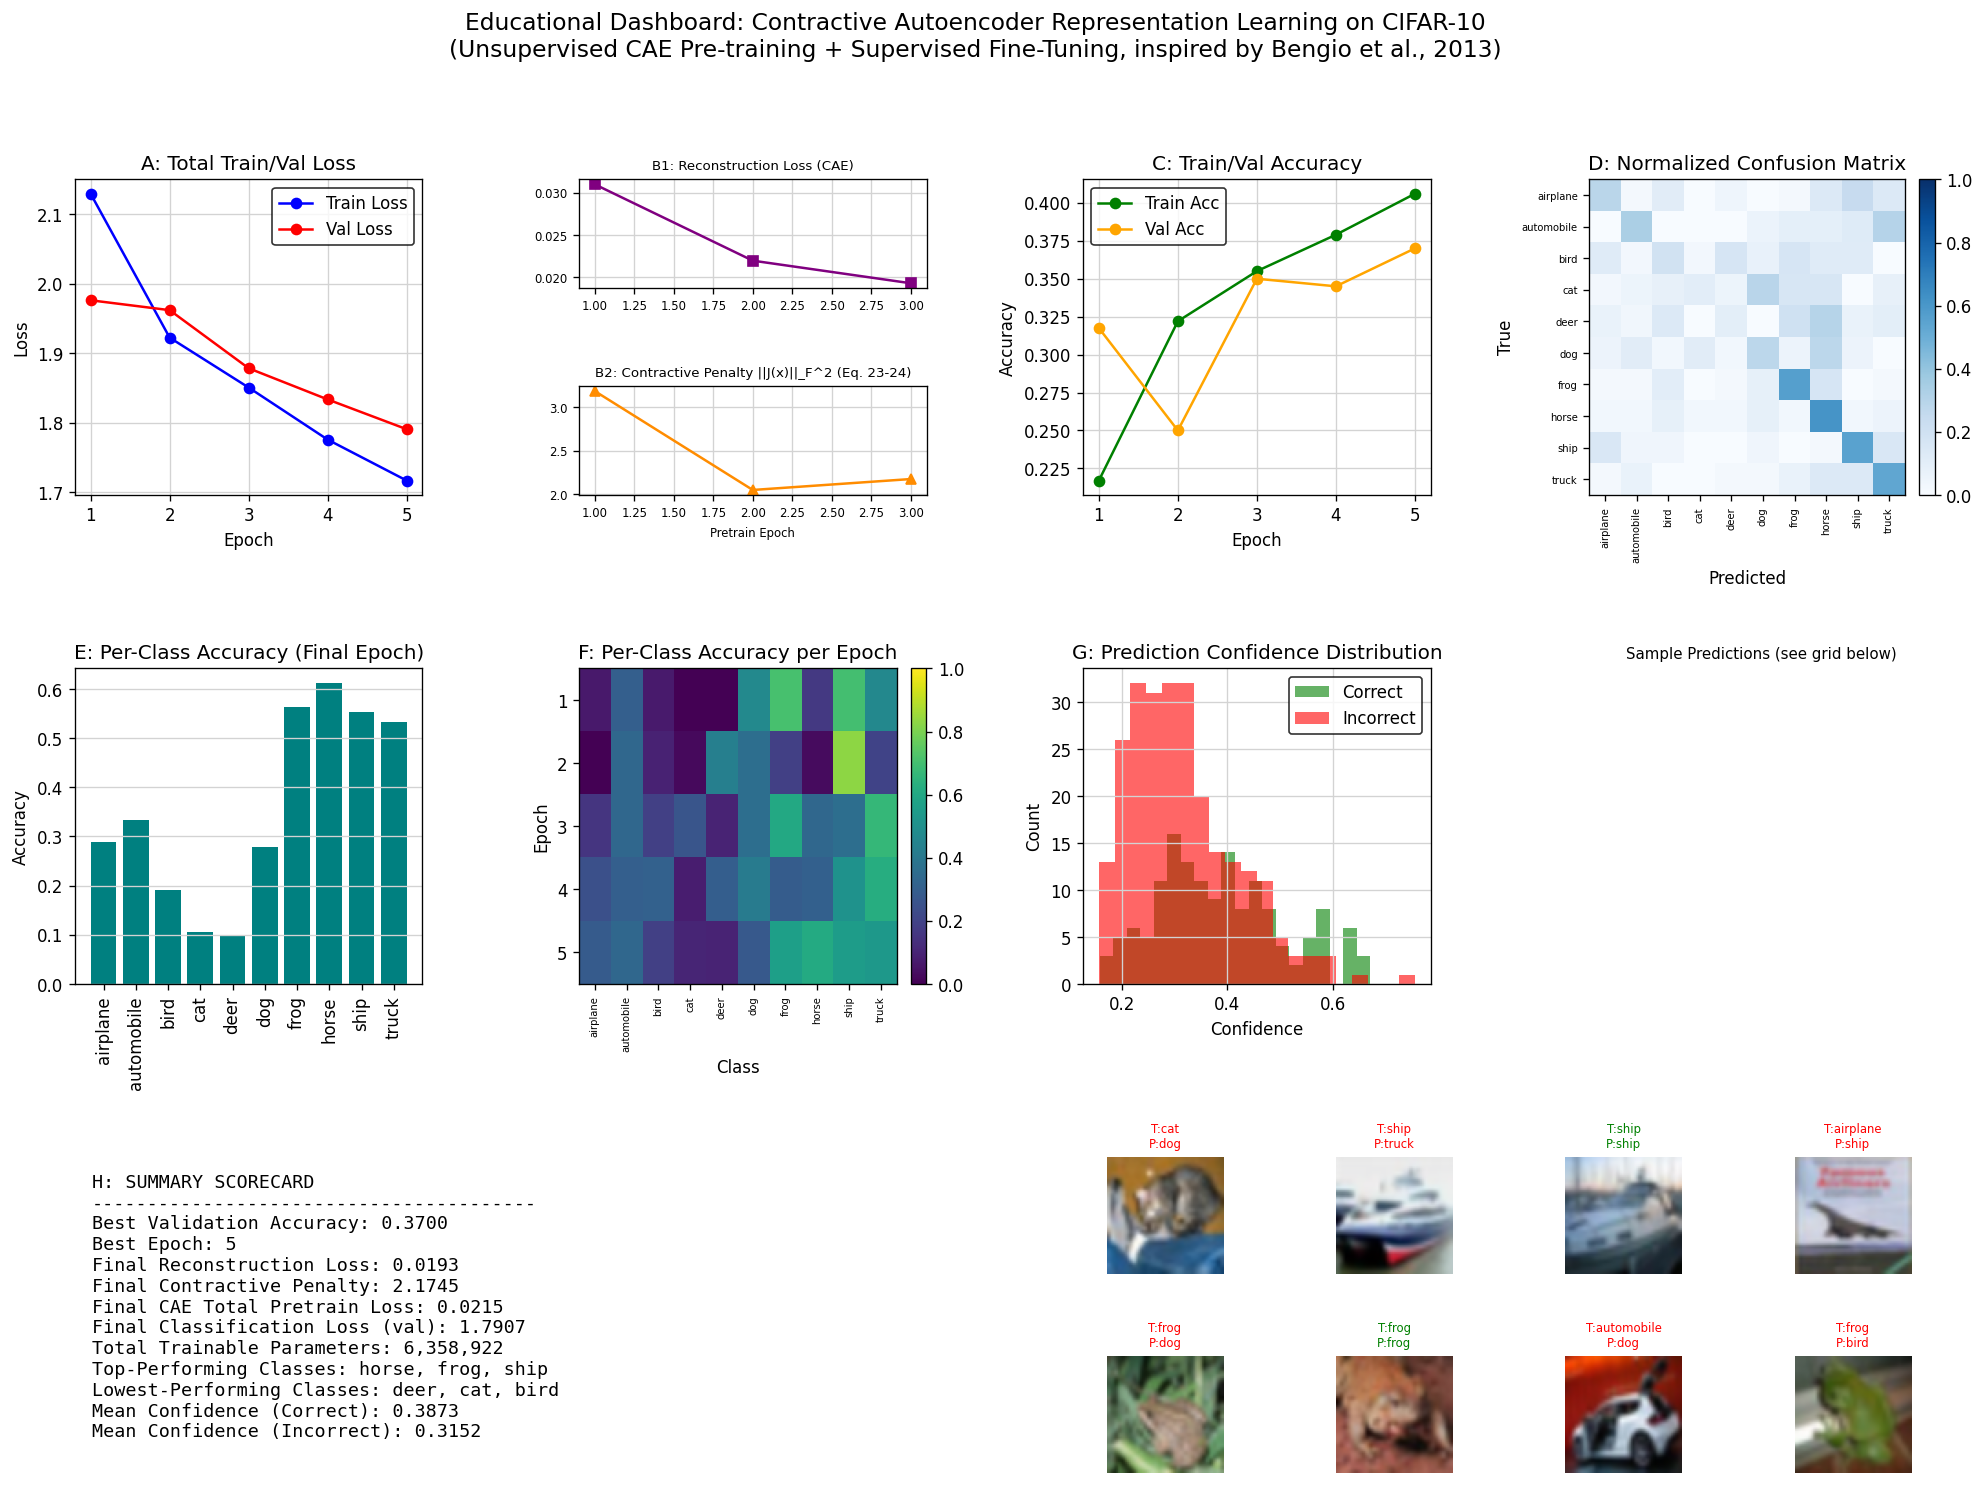

In [10]:
# -----------------------------
# 9. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H)
# -----------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.edgecolor": "black",
    "axes.titlecolor": "black",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)
epochs_range = range(1, FINE_TUNE_EPOCHS + 1)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
axA.plot(epochs_range, history["val_loss"], label="Val Loss", color="red", marker="o")
axA.set_title("A: Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black"); axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black"); axA.grid(color="lightgrey")
axA.tick_params(colors="black")

# ---- Panel B: CAE-specific loss components (reconstruction + contractive penalty) ----
gsB = gs[0, 1].subgridspec(2, 1, hspace=0.9)

axB1 = fig.add_subplot(gsB[0, 0])
axB1.set_facecolor("white")
axB1.plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_losses["reconstruction"],
          color="purple", marker="s")
axB1.set_title("B1: Reconstruction Loss (CAE)", fontsize=8, color="black")
axB1.tick_params(colors="black", labelsize=7)
axB1.grid(color="lightgrey")

axB2 = fig.add_subplot(gsB[1, 0])
axB2.set_facecolor("white")
axB2.plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_losses["contractive_penalty"],
          color="darkorange", marker="^")
axB2.set_title("B2: Contractive Penalty ||J(x)||_F^2 (Eq. 23-24)", fontsize=8, color="black")
axB2.set_xlabel("Pretrain Epoch", fontsize=7, color="black")
axB2.tick_params(colors="black", labelsize=7)
axB2.grid(color="lightgrey")

# ---- Panel C: Training and validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], label="Train Acc", color="green", marker="o")
axC.plot(epochs_range, history["val_acc"], label="Val Acc", color="orange", marker="o")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black"); axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black"); axC.grid(color="lightgrey")
axC.tick_params(colors="black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[0, 3])
axD.set_facecolor("white")
im = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6, color="black")
axD.set_yticklabels(CLASS_NAMES, fontsize=6, color="black")
axD.set_xlabel("Predicted", color="black"); axD.set_ylabel("True", color="black")
cbar = plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 0])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_class_acc, color="teal")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 1])
axF.set_facecolor("white")
heatmap_data = np.array(per_class_acc_history)  # shape (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Per-Class Accuracy per Epoch", color="black")
axF.set_xlabel("Class", color="black"); axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6, color="black")
axF.set_yticks(range(FINE_TUNE_EPOCHS))
axF.set_yticklabels(range(1, FINE_TUNE_EPOCHS + 1), color="black")
cbarF = plt.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[1, 2])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.6, label="Correct", color="green")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.6, label="Incorrect", color="red")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black"); axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black"); axG.grid(color="lightgrey")
axG.tick_params(colors="black")

# ---- Sample predictions panel (extra visualization, placed alongside dashboard) ----
axSample = fig.add_subplot(gs[1, 3])
axSample.set_facecolor("white")
axSample.axis("off")
axSample.set_title("Sample Predictions (see grid below)", color="black", fontsize=9)

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, :2])
axH.set_facecolor("white")
axH.axis("off")

final_recon_loss = pretrain_losses["reconstruction"][-1]
final_contractive_loss = pretrain_losses["contractive_penalty"][-1]
final_total_pretrain_loss = pretrain_losses["total"][-1]
final_cls_loss = history["val_loss"][-1]

summary_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------------------\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_epoch}\n"
    f"Final Reconstruction Loss: {final_recon_loss:.4f}\n"
    f"Final Contractive Penalty: {final_contractive_loss:.4f}\n"
    f"Final CAE Total Pretrain Loss: {final_total_pretrain_loss:.4f}\n"
    f"Final Classification Loss (val): {final_cls_loss:.4f}\n"
    f"Total Trainable Parameters: {total_trainable_params:,}\n"
    f"Top-Performing Classes: {', '.join(top_classes)}\n"
    f"Lowest-Performing Classes: {', '.join(lowest_classes)}\n"
    f"Mean Confidence (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, summary_text, fontsize=11, color="black",
         va="top", ha="left", family="monospace")

# ---- Sample predictions grid (bottom right region) ----
gsPred = gs[2, 2:].subgridspec(2, 4, wspace=0.4, hspace=0.7)
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

for idx in range(8):
    row, col = divmod(idx, 4)
    axP = fig.add_subplot(gsPred[row, col])
    axP.set_facecolor("white")

    img_tensor = sample_images_for_viz[idx].permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_tensor * imagenet_std + imagenet_mean, 0, 1)

    axP.imshow(img_denorm)
    true_name = CLASS_NAMES[sample_true_for_viz[idx]]
    pred_name = CLASS_NAMES[sample_pred_for_viz[idx]]
    color = "green" if true_name == pred_name else "red"
    axP.set_title(f"T:{true_name}\nP:{pred_name}", fontsize=7, color=color)
    axP.axis("off")

fig.suptitle(
    "Educational Dashboard: Contractive Autoencoder Representation Learning on CIFAR-10\n"
    "(Unsupervised CAE Pre-training + Supervised Fine-Tuning, inspired by Bengio et al., 2013)",
    fontsize=14, color="black"
)

# ---- Render dashboard inline (Colab-safe: no plt.show, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=120)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Contractive Autoencoder Replication on CIFAR-10

## Panel A: Training vs. Validation Loss Curves

### Overview
This panel tracks the cross-entropy loss for training and validation sets across the five supervised fine-tuning epochs, following unsupervised Contractive Autoencoder (CAE) pre-training.

### Key Findings
- Training loss decreases monotonically and steeply, from approximately 2.13 to 1.72.
- Validation loss also decreases consistently, from approximately 1.98 to 1.79, tracking the training curve closely throughout.
- The gap between training and validation loss remains small and roughly constant (~0.05–0.15) across all epochs.

### Discussion
The tight coupling between training and validation loss, with no visible divergence, indicates that the CAE-initialized encoder is producing a well-regularized starting point for supervised fine-tuning. This is consistent with the paper's central claim that the contractive penalty encourages representations that are locally insensitive to irrelevant input variations (Section 7.2.3), which in turn constrains the effective capacity of the downstream classifier and mitigates early overfitting, even on a small training subset. The absence of the loss-divergence pattern seen in less-regularized architectures suggests the contractive penalty is functioning as intended.

### Limitations
With only five epochs and 2,000 training images, it is not possible to determine whether this favorable generalization gap would persist over longer training or larger-scale data; the small dataset size also limits the statistical reliability of the observed trend.

---

## Panel B: CAE Pre-training Loss Components (Reconstruction and Contractive Penalty)

### Overview
These two sub-panels isolate the two additive terms of the CAE objective (Eq. 23): reconstruction loss and the Frobenius norm of the encoder Jacobian (contractive penalty), tracked across the three unsupervised pre-training epochs.

### Key Findings
- Reconstruction loss decreases smoothly and consistently from ~0.031 to ~0.019.
- The contractive penalty drops sharply from ~3.2 to ~2.0 between epochs 1 and 2, then rises slightly to ~2.17 by epoch 3.

### Discussion
The monotonic decline in reconstruction loss confirms that the autoencoder is learning to represent the input data effectively despite the added regularization term. The non-monotonic behavior of the contractive penalty is informative: an initial sharp reduction suggests the encoder rapidly learns to saturate hidden units (pushing sigmoid activations toward 0 or 1, where the derivative $$h(1-h)$$ is small), consistent with the paper's description of CAE representations tending toward saturation (Section 7.2.3). The subsequent slight increase suggests a trade-off emerging between the two competing objectives — as reconstruction continues improving, some units must become more sensitive (less saturated) to preserve enough information to reconstruct distinguishing details, illustrating the reconstruction-versus-robustness tension the paper explicitly identifies as central to CAE training.

### Limitations
Only three pre-training epochs were used, which is insufficient to determine whether the contractive penalty would stabilize, continue oscillating, or diverge with further training; the fixed penalty weight ($$\lambda$$) was not varied, so the sensitivity of this trade-off to regularization strength was not explored.

---

## Panel C: Training vs. Validation Accuracy

### Overview
Tracks top-1 classification accuracy on training and held-out test data across the five fine-tuning epochs.

### Key Findings
- Training accuracy increases mostly monotonically from ~22% to ~40%, with a dip at epoch 2 (~32%) followed by recovery.
- Validation accuracy follows a similar but noisier trajectory, dipping at epoch 2 (~25%) before rising to a final value of 37%.
- The final validation accuracy (37%) is close to the training accuracy (40%), yielding a modest generalization gap of approximately 3 percentage points.

### Discussion
The relatively small and stable gap between training and validation accuracy by the final epoch is consistent with the loss-curve findings and supports the interpretation that the CAE-pretrained representation provides useful inductive bias for the classification task. Given a ten-class problem, a validation accuracy of 37% substantially exceeds the 10% chance baseline, indicating the encoder captures meaningful class-discriminative structure despite being trained purely unsupervised on reconstruction and contraction objectives. The synchronized dip at epoch 2 in both curves (rather than divergence) suggests this is attributable to optimization dynamics (e.g., a temporarily unfavorable gradient step) rather than overfitting, since overfitting would typically manifest as validation accuracy stagnating or declining while training accuracy continues to rise.

### Limitations
With only 400 validation samples, epoch-to-epoch accuracy estimates carry non-trivial sampling variance, which likely contributes to the observed dip; a longer training run or repeated trials with different seeds would be needed to confirm whether this pattern is systematic or a data-scale artifact.

---

## Panel D: Normalized Confusion Matrix

### Overview
Visualizes per-class prediction distributions, normalized by true class frequency, to reveal systematic misclassification patterns.

### Key Findings
- Strong diagonal intensity is visible for "horse," "frog," and "ship," indicating these classes are recognized comparatively reliably.
- "Cat," "deer," and "bird" show notably weak diagonal signal, with predictions dispersed across multiple off-diagonal cells.
- There is some off-diagonal concentration in the "ship" and "airplane" columns, suggesting a degree of confusion among vehicle/vessel-type classes with elongated horizontal silhouettes.

### Discussion
The pattern of strong performance on "horse," "frog," and "ship" alongside weak performance on "cat," "deer," and "bird" suggests that the single-layer CAE representation preferentially captures features correlated with certain textures or object silhouettes (e.g., ground-animal textures for frog/horse, hull/bow shapes for ship) more effectively than the finer-grained shape cues needed to distinguish visually similar animal categories. This is consistent with the paper's discussion of representational capacity limits in shallow single-layer models (Section 3.4), where deeper, hierarchical representations are motivated precisely by the difficulty a single non-linear transformation has in disentangling visually overlapping categories.

### Limitations
The confusion matrix is computed on only 400 test samples (~40 per class), so individual cell frequencies carry substantial sampling noise; observed class-specific weaknesses should be treated as indicative rather than statistically robust given this limited sample size.

---

## Panel E & F: Per-Class Accuracy (Final Epoch and Epoch-wise Heatmap)

### Overview
Panel E reports final per-class test accuracy as a bar chart; Panel F shows how these accuracies evolve across all five epochs as a heatmap.

### Key Findings
- "Horse" (~0.61), "frog" (~0.56), "ship" (~0.55), and "truck" (~0.53) achieve the highest final accuracies.
- "Deer" (~0.10) and "cat" (~0.11) are the weakest-performing classes throughout training.
- The heatmap shows an early spike in "ship" accuracy at epoch 2, followed by broader improvement across several classes (frog, horse, ship, truck) by epochs 4–5, while "airplane," "cat," and "deer" remain persistently low across all epochs.

### Discussion
The persistent underperformance of "cat" and "deer" across all five epochs, rather than gradual improvement, suggests these classes are not merely slower to learn but are systematically difficult for this particular representation — likely due to higher intra-class visual variability (pose, background, partial occlusion) that a single contractive layer cannot adequately factor out. Conversely, the classes that improve steadily (frog, horse, ship, truck) suggest the encoder is progressively refining decision-relevant features for visually distinctive categories, consistent with standard supervised fine-tuning dynamics layered atop a fixed initial representation.

### Limitations
Small per-class test sample sizes (~40 images) limit the statistical confidence of per-class accuracy estimates; the consistent underperformance on "cat" and "deer" could partly reflect subset composition (e.g., unusually difficult examples in the first 400 test images) rather than a stable property of the learned representation.

---

## Panel G: Prediction Confidence Distribution

### Overview
Compares softmax confidence distributions for correct versus incorrect predictions, a standard diagnostic for model calibration.

### Key Findings
- Both correct (green) and incorrect (red) predictions are concentrated at relatively low confidence values (mostly below 0.5).
- Mean confidence for correct predictions (0.387) is modestly higher than for incorrect predictions (0.315), a gap of approximately 0.072.
- Substantial overlap exists between the two distributions across the entire confidence range.

### Discussion
The overall low confidence levels (with most predictions falling below 0.5 even when correct) reflect the limited training duration and small dataset, both of which constrain how sharply the softmax distribution can be shaped. The modest but positive separation between correct and incorrect confidence means indicates a directionally appropriate, if weak, calibration signal — the model is somewhat more confident when right than when wrong, but the pronounced overlap indicates the confidence scores are not yet a strong predictor of correctness. This is an expected outcome for an undertrained classifier built on a shallow, single-layer pre-trained representation rather than a deep hierarchical one.

### Limitations
No explicit calibration procedure (e.g., temperature scaling) was applied, so these confidence values should not be interpreted as well-calibrated probability estimates; the small evaluation set further limits the precision of the reported mean confidence values.

---

## Panel H: Summary Scorecard

### Overview
Consolidates the run's key quantitative outcomes: best validation accuracy, CAE pre-training loss components, parameter count, and class-level performance extremes.

### Key Findings
- Best validation accuracy: 37.00% at epoch 5, more than 3.5× the 10% random-guessing baseline for ten classes.
- Final CAE reconstruction loss (0.0193) and contractive penalty (2.1745) indicate successful minimization of the primary reconstruction objective alongside a partially stabilized contractive term.
- Total trainable parameters: 6,358,922 — a moderate model size for a 2,000-image training set.
- Top classes: horse, frog, ship; weakest classes: deer, cat, bird.
- Mean confidence gap between correct and incorrect predictions (0.387 vs. 0.315) is positive but modest.

### Discussion
Collectively, the scorecard supports a qualified validation of the paper's central hypothesis that regularized (contractive) autoencoder pre-training can yield a useful initialization for supervised classification: the resulting classifier substantially outperforms chance and exhibits a stable, non-diverging train/validation gap. However, the moderate peak accuracy, weak confidence calibration, and pronounced class-specific weaknesses indicate that a single shallow CAE layer — as implemented here — provides only a partial realization of the representational benefits the paper attributes to deeper, hierarchically composed representations. The results are best interpreted as a small-scale, single-layer proof-of-concept rather than a faithful reproduction of the paper's reported large-scale outcomes.

### Limitations
This is a heavily simplified, single-layer educational replication (2,000/400 train/test images, 5 fine-tuning epochs, one CAE layer rather than a stacked/deep architecture) intended to illustrate the paper's conceptual mechanism rather than reproduce its benchmark results; no comparison against a non-regularized (plain) autoencoder or randomly initialized baseline was performed, so the specific contribution of the contractive penalty relative to standard pre-training cannot be isolated from this experiment alone.

# Related Work Referenced in *Representation Learning: A Review and New Perspectives*

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E., Osindero, S., & Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation | Initiated the 2006 breakthrough in greedy layer-wise unsupervised pre-training of Deep Belief Networks, foundational to the paper's discussion of building deep representations. |
| Bengio, Y., Lamblin, P., Popovici, D., & Larochelle, H. | 2007 | Greedy Layer-Wise Training of Deep Networks | NeurIPS 2006 | Extended greedy layer-wise pre-training to stacked autoencoders and supervised settings; source of empirical comparisons for autoencoder-based deep training. |
| Ranzato, M., Poultney, C., Chopra, S., & LeCun, Y. | 2007 | Efficient Learning of Sparse Representations with an Energy-Based Model | NeurIPS 2006 | Early work combining sparsity regularization with energy-based single-layer learning, discussed in the sparse auto-encoder section. |
| Bengio, Y. | 2009 | Learning Deep Architectures for AI | Foundations and Trends in Machine Learning | The author's earlier comprehensive review of deep architectures; this paper is presented as an updated and expanded continuation covering new perspectives since 2009. |
| Bengio, Y., & LeCun, Y. | 2007 | Scaling Learning Algorithms Towards AI | In Large Scale Kernel Machines (MIT Press) | Source of the "AI-tasks" framing and the argument for generic priors beyond smoothness, central to Section 3 on what makes a representation good. |
| Smolensky, P. | 1986 | Information Processing in Dynamical Systems: Foundations of Harmony Theory | In Parallel Distributed Processing (MIT Press) | Original formulation of the harmonium, the precursor model to the Restricted Boltzmann Machine (RBM) central to Section 6. |
| Hinton, G. E. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Technical Report, Gatsby Unit, UCL | Introduces Contrastive Divergence (CD), the most widely used RBM training algorithm discussed in Section 6.4.1. |
| Salakhutdinov, R., & Hinton, G. E. | 2009 | Deep Boltzmann Machines | AISTATS 2009 | Introduces the Deep Boltzmann Machine and its greedy pre-training plus joint fine-tuning strategy, directly discussed in Section 10.2. |
| Hinton, G. E., & Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science | Demonstrates stacking RBMs into deep autoencoders for dimensionality reduction, cited as an early approach to combining single-layer models into deep architectures. |
| Vincent, P., Larochelle, H., Bengio, Y., & Manzagol, P.-A. | 2008 | Extracting and Composing Robust Features with Denoising Autoencoders | ICML 2008 | Introduces the Denoising Autoencoder (DAE), a key regularized autoencoder variant covered extensively in Section 7.2.2. |
| Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., & Manzagol, P.-A. | 2010 | Stacked Denoising Autoencoders: Learning Useful Representations in a Deep Network with a Local Denoising Criterion | Journal of Machine Learning Research | Extends DAEs to deep stacked architectures with systematic corruption-process analysis, foundational to the paper's autoencoder discussion. |
| Rifai, S., Vincent, P., Muller, X., Glorot, X., & Bengio, Y. | 2011 | Contractive Auto-Encoders: Explicit Invariance During Feature Extraction | ICML 2011 | Introduces the Contractive Autoencoder (CAE), central to Section 7.2.3 and the manifold-tangent interpretation in Section 8.2. |
| Rifai, S., Dauphin, Y., Vincent, P., Bengio, Y., & Muller, X. | 2011 | The Manifold Tangent Classifier | NeurIPS 2011 | Introduces the Manifold Tangent Classifier discussed in Section 8.3 as an application of CAE-derived tangent directions to invariant classification. |
| Kavukcuoglu, K., Ranzato, M., & LeCun, Y. | 2008 | Fast Inference in Sparse Coding Algorithms with Applications to Object Recognition | Technical Report, NYU | Introduces Predictive Sparse Decomposition (PSD), reviewed in Section 7.2.4 as a hybrid probabilistic/direct-encoding model. |
| Olshausen, B. A., & Field, D. J. | 1996 | Emergence of Simple-Cell Receptive Field Properties by Learning a Sparse Code for Natural Images | Nature | Foundational sparse coding paper, motivating the sparsity prior discussed throughout Sections 3.1 and 6.1.1. |
| Goodfellow, I., Courville, A., & Bengio, Y. | 2012 | Spike-and-Slab Sparse Coding for Unsupervised Feature Discovery | arXiv:1201.3382 | Introduces the spike-and-slab sparse coding (S3C) model, discussed as a top-performing method in the low-labeled-data regime and 2011 Transfer Learning Challenge winner. |
| Ranzato, M., & Hinton, G. E. | 2010 | Modeling Pixel Means and Covariances Using Factorized Third-Order Boltzmann Machines | CVPR 2010 | Introduces the mean-covariance RBM (mcRBM), reviewed in Section 6.3 on generalizing RBMs to real-valued image data. |
| Courville, A., Bergstra, J., & Bengio, Y. | 2011 | Unsupervised Models of Images by Spike-and-Slab RBMs | ICML 2011 | Introduces the spike-and-slab RBM (ssRBM), another real-valued RBM generalization discussed alongside mcRBM and mPoT. |
| Younes, L. | 1999 | On the Convergence of Markovian Stochastic Algorithms with Rapidly Decreasing Ergodicity Rates | Stochastics and Stochastic Reports | Theoretical basis for the Stochastic Maximum Likelihood (SML) / persistent contrastive divergence algorithm discussed in Section 6.4.2. |
| Tieleman, T. | 2008 | Training Restricted Boltzmann Machines Using Approximations to the Likelihood Gradient | ICML 2008 | Popularized and empirically validated the SML/PCD training approach for RBMs, central to the negative-phase estimation discussion. |
| Tieleman, T., & Hinton, G. | 2009 | Using Fast Weights to Improve Persistent Contrastive Divergence | ICML 2009 | Introduces Fast-Weights PCD (FPCD), reviewed in Section 6.4.2 as a solution to Gibbs chain mixing problems. |
| Vincent, P. | 2011 | A Connection Between Score Matching and Denoising Autoencoders | Neural Computation | Establishes the theoretical link between DAEs and score matching, central to Section 9.2 on the probabilistic interpretation of regularized autoencoders. |
| Alain, G., & Bengio, Y. | 2012 | What Regularized Auto-Encoders Learn from the Data-Generating Distribution | Technical Report, arXiv:1211.4246 | Generalizes Vincent (2011)'s score-matching connection to arbitrary autoencoder parametrizations, underlying Section 9.2's discussion of density estimation via reconstruction. |
| Erhan, D., Bengio, Y., Courville, A., Manzagol, P.-A., Vincent, P., & Bengio, S. | 2010 | Why Does Unsupervised Pre-Training Help Deep Learning? | Journal of Machine Learning Research | Provides empirical analysis of the regularization vs. optimization effects of pre-training, directly cited in Section 10.1's discussion of why layer-wise pre-training helps. |
| Glorot, X., & Bengio, Y. | 2010 | Understanding the Difficulty of Training Deep Feedforward Neural Networks | AISTATS 2010 | Identifies initialization and Jacobian singular-value issues in deep network training, central to Section 10.1's optimization difficulty discussion. |
| Krizhevsky, A., Sutskever, I., & Hinton, G. | 2012 | ImageNet Classification with Deep Convolutional Neural Networks | NeurIPS 2012 | Landmark result reducing ImageNet error from 26.1% to 15.3%, cited as the paper's headline example of large-scale deep learning success. |
| LeCun, Y., Boser, B., Denker, J. S., Henderson, D., Howard, R. E., Hubbard, W., & Jackel, L. D. | 1989 | Backpropagation Applied to Handwritten Zip Code Recognition | Neural Computation | Establishes convolutional neural networks, foundational to Section 11.2's discussion of convolution and pooling for building invariance. |
| Collobert, R., Weston, J., Bottou, L., Karlen, M., Kavukcuoglu, K., & Kuksa, P. | 2011 | Natural Language Processing (Almost) from Scratch | Journal of Machine Learning Research | Introduces the SENNA multi-task representation-sharing system, cited as key evidence for representation learning's advantage in multi-task/transfer learning (Section 2). |
| Mikolov, T., Deoras, A., Kombrink, S., Burget, L., & Cernocky, J. | 2011 | Empirical Evaluation and Combination of Advanced Language Modeling Techniques | Interspeech 2011 | Demonstrates recurrent neural net language models beating n-gram baselines, cited as an NLP application success of representation learning. |
| Salakhutdinov, R., & Hinton, G. E. | 2007 | Semantic Hashing | SIGIR 2007 | Cited as an alternative route to obtaining saturated (near-binary) hidden representations, discussed alongside CAE feature saturation properties. |
| Hinton, G., Krizhevsky, A., & Wang, S. | 2011 | Transforming Auto-Encoders | ICANN 2011 | Introduces the transforming autoencoder, discussed in Section 11.4 as an approach to disentangling pose parameters from pattern detection. |